In [1]:
import os   
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns  

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Paths
DATA_PATH = "../data/diabetic_data.csv"
PLOT_DIR = "../docs/plots"
MODEL_DIR = "../app/model"
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

### 1. Loading dataset

In [3]:
df = pd.read_csv(DATA_PATH)

print(f"  Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  Column names  :\n {list(df.columns)}")
print('/n')
print(f"  Data types    :\n{df.dtypes.to_string()}")
print('/n')
print(f"  First 3 rows  :\n{df.head(5).to_string()}")

  Shape         : 101,766 rows × 50 columns
  Memory usage  : 202.2 MB
  Column names  :
 ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']
/n
  Data types    :
encounter_id                 int64
patient_nbr                  int64
r

### 2. Initial Exploration

In [4]:
# Replace '?' with NaN  ← actual missing value marker in this dataset
df.replace("?", np.nan, inplace=True)

print("\nMissing values per column:")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing.to_string())


Missing values per column:
weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21


In [5]:
print(f"\n  Target distribution (readmitted):")
print(df["readmitted"].value_counts().to_string())


  Target distribution (readmitted):
readmitted
NO     54864
>30    35545
<30    11357


In [6]:
print(f"\n  Numeric summary:")
print(df.describe().to_string())


  Numeric summary:
       encounter_id   patient_nbr  admission_type_id  discharge_disposition_id  admission_source_id  time_in_hospital  num_lab_procedures  num_procedures  num_medications  number_outpatient  number_emergency  number_inpatient  number_diagnoses
count  1.017660e+05  1.017660e+05      101766.000000             101766.000000        101766.000000     101766.000000       101766.000000   101766.000000    101766.000000      101766.000000     101766.000000     101766.000000     101766.000000
mean   1.652016e+08  5.433040e+07           2.024006                  3.715642             5.754437          4.395987           43.095641        1.339730        16.021844           0.369357          0.197836          0.635566          7.422607
std    1.026403e+08  3.869636e+07           1.445403                  5.280166             4.064081          2.985108           19.674362        1.705807         8.127566           1.267265          0.930472          1.262863          1.933600
min 

### 3. Data Cleaning & Transformation

In [7]:
# 3-a  DROP columns with >90% missing (weight: 97%)
df.drop(columns=["weight", "payer_code"], inplace=True)
print("  Dropped 'weight' (97% missing) and 'payer_code' (40% missing).")

  Dropped 'weight' (97% missing) and 'payer_code' (40% missing).


In [8]:
# 3-b  DROP non-predictive ID columns
df.drop(columns=["encounter_id", "patient_nbr"], inplace=True)
print("  Dropped identifier columns: encounter_id, patient_nbr.")

  Dropped identifier columns: encounter_id, patient_nbr.


In [9]:
# 3-c  Drop rows where medical_specialty or race is missing (remaining ~5%)
df.dropna(subset=["race", "medical_specialty"], inplace=True)
print(f"  After dropping rows with missing race/medical_specialty: {df.shape}")

  After dropping rows with missing race/medical_specialty: (50727, 46)


In [10]:
# 3-d  Fill remaining NaNs in diag_* with mode
for col in ["diag_1", "diag_2", "diag_3"]:
    df[col] = df[col].fillna(df[col].mode()[0])
print("  Imputed diag_1/2/3 missing values with column mode.")

  Imputed diag_1/2/3 missing values with column mode.


In [11]:
# 3-e  TARGET ENCODING — binary: <30 → 1 (readmitted early), else → 0
df["readmitted"] = (df["readmitted"] == "<30").astype(int)
print(f"\n  Binary target created: 1 = readmitted <30 days")
print(f"  Class balance: {df['readmitted'].value_counts().to_dict()}")


  Binary target created: 1 = readmitted <30 days
  Class balance: {0: 45250, 1: 5477}


In [12]:
# 3-f  AGE — convert bracket to ordinal integer (midpoint)
age_map = {
    "[0-10)": 5, "[10-20)": 15, "[20-30)": 25, "[30-40)": 35,
    "[40-50)": 45, "[50-60)": 55, "[60-70)": 65, "[70-80)": 75,
    "[80-90)": 85, "[90-100)": 95
}
df["age"] = df["age"].map(age_map)
print("  Age brackets converted to numeric midpoints.")

  Age brackets converted to numeric midpoints.


In [13]:
# 3-g  MEDICATION columns — map to ordinal: No→0, Steady→1, Up/Down→2
med_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "acetohexamide", "glipizide", "glyburide",
    "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
    "miglitol", "troglitazone", "tolazamide", "examide",
    "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone"
]
med_map = {"No": 0, "Steady": 1, "Up": 2, "Down": 2}
for col in med_cols:
    if col in df.columns:
        df[col] = df[col].map(med_map).fillna(0).astype(int)
print(f"  Mapped {len(med_cols)} medication columns to ordinal [0,1,2].")

  Mapped 23 medication columns to ordinal [0,1,2].


In [14]:
# 3-h  BINARY categoricals — change, diabetesMed
binary_map = {"Ch": 1, "No": 0, "Yes": 1}
df["change"]      = df["change"].map(binary_map).fillna(0).astype(int)
df["diabetesMed"] = df["diabetesMed"].map({"Yes": 1, "No": 0}).astype(int)

In [15]:
# 3-i  MAX_GLU_SERUM & A1CRESULT — ordinal encode categories
glu_map    = {np.nan: 0, "Norm": 1, ">200": 2, ">300": 3}
a1c_map    = {np.nan: 0, "Norm": 1, ">7": 2, ">8": 3}
df["max_glu_serum"] = df["max_glu_serum"].map(glu_map).fillna(0).astype(int)
df["A1Cresult"]     = df["A1Cresult"].map(a1c_map).fillna(0).astype(int)
print("  Ordinal-encoded max_glu_serum and A1Cresult.")

  Ordinal-encoded max_glu_serum and A1Cresult.


In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
# 3-j  HIGH-CARDINALITY cols — Label-encode race, gender, medical_specialty
le = LabelEncoder()
for col in ["race", "gender", "medical_specialty", "diag_1", "diag_2", "diag_3"]:
    df[col] = le.fit_transform(df[col].astype(str))
print("  Label-encoded: race, gender, medical_specialty, diag_1-3.")

print(f"\n  Clean dataset shape: {df.shape}")
print(f"  Remaining NaNs: {df.isnull().sum().sum()}")

  Label-encoded: race, gender, medical_specialty, diag_1-3.

  Clean dataset shape: (50727, 46)
  Remaining NaNs: 0


### 4. Exploratory Data Analysis 

##### Plot 1: Target class distribution

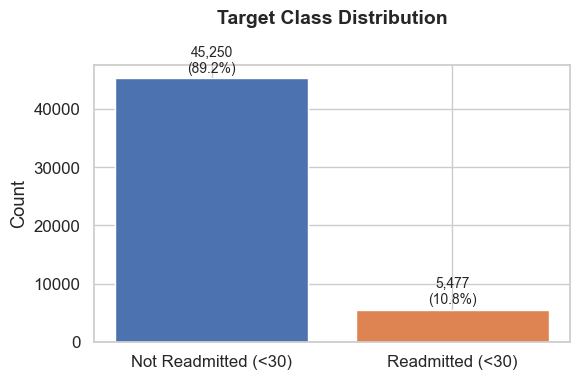

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["readmitted"].value_counts()

labels = ["Not Readmitted (<30)", "Readmitted (<30)"]
colors = ["#4C72B0", "#DD8452"]
bars = ax.bar(labels, counts.values, color = colors)

# Titles and labels
ax.set_title("Target Class Distribution", fontsize=14, fontweight="bold", pad = 30)
ax.set_ylabel("Count")

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
    bar.get_height() + 500,
    f'{count:,}\n({count/len(df)*100:.1f}%)',
    ha = 'center', va = 'bottom', fontsize=10) 
    
plt.tight_layout()
plt.show()

plt.savefig(f"{PLOT_DIR}/01_target_distribution.png", dpi=150)
plt.close()

##### Plot 2: Age distribution by readmission

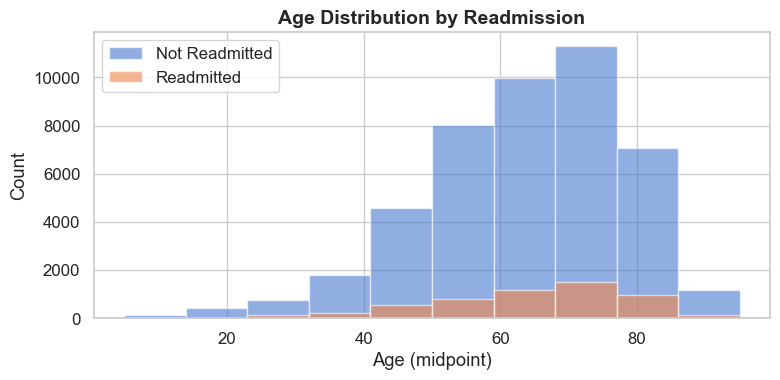

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in df.groupby("readmitted"):
    ax.hist(grp["age"], bins=10, alpha=0.6,
            label="Readmitted" if label == 1 else "Not Readmitted")
    
ax.set_title("Age Distribution by Readmission", fontsize=14, fontweight="bold")
ax.set_xlabel("Age (midpoint)")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
plt.show()

plt.savefig(f"{PLOT_DIR}/02_age_distribution.png", dpi=150)
plt.close()

##### Plot 3: Correlation heatmap (numeric features) 

In [20]:
print(df.columns.tolist())

['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


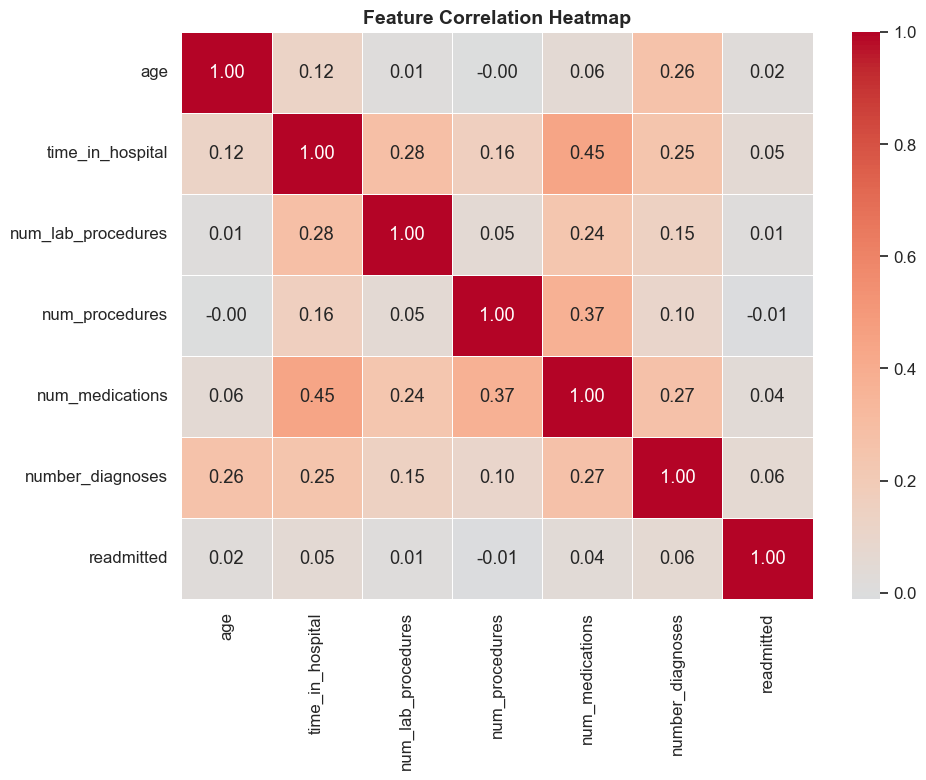

In [21]:
num_features = ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'readmitted']
corr = df[num_features].corr()
fig, ax = plt.subplots(figsize = (10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center = 0, ax = ax, linewidths= 0.5)

ax.set_title('Feature Correlation Heatmap', fontsize= 14, fontweight= 'bold')
plt.tight_layout()
plt.show()

plt.savefig(f'{PLOT_DIR}/03_correlation_heatmap.png', dpi= 150)
plt.close()

##### Plot 4: Time in hospital boxplot

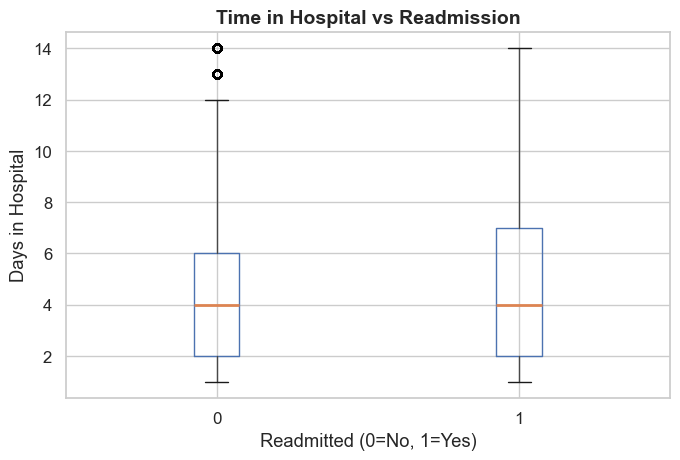

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
df.boxplot(column="time_in_hospital", by="readmitted", ax=ax,
           boxprops=dict(color="#4C72B0"),
           medianprops=dict(color="#DD8452", linewidth=2))
ax.set_title("Time in Hospital vs Readmission", fontsize=14, fontweight="bold")
ax.set_xlabel("Readmitted (0=No, 1=Yes)")
ax.set_ylabel("Days in Hospital")
plt.suptitle("")
plt.tight_layout()
plt.show()
plt.savefig(f"{PLOT_DIR}/04_time_in_hospital_boxplot.png", dpi=150)
plt.close()

##### Plot 5: Insulin effect on readmission

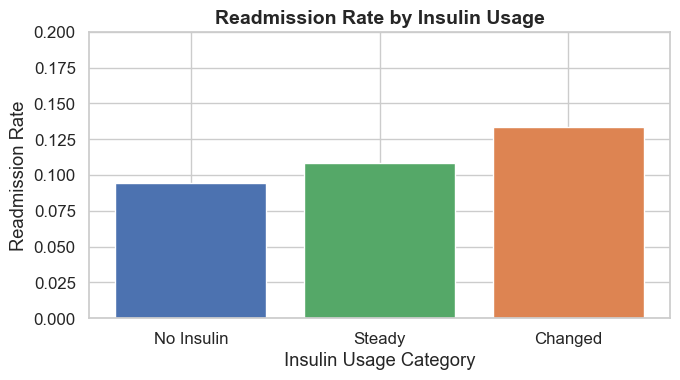

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
insulin_read = df.groupby("insulin")["readmitted"].mean().reset_index()

ax.bar(["No Insulin", "Steady", "Changed"], insulin_read["readmitted"],
       color=["#4C72B0", "#55A868", "#DD8452"])
ax.set_title("Readmission Rate by Insulin Usage", fontsize=14, fontweight="bold")
ax.set_ylabel("Readmission Rate")
ax.set_xlabel("Insulin Usage Category")
ax.set_ylim(0, 0.2)

plt.tight_layout()
plt.show()

plt.savefig(f"{PLOT_DIR}/05_insulin_readmission.png", dpi=150)
plt.close()

##### Plot 6: Top diagnoses

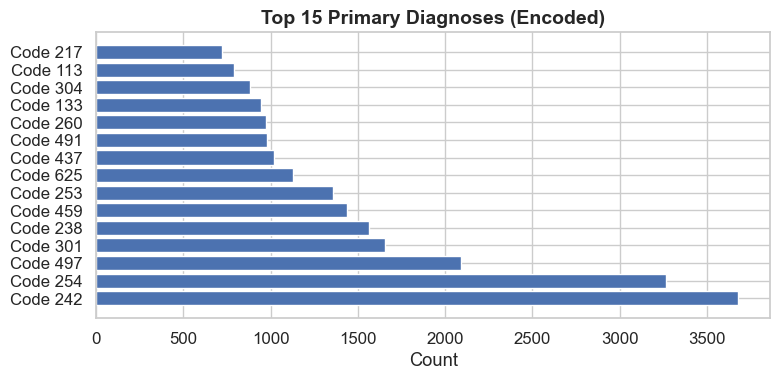

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
top_diag = df["diag_1"].value_counts().head(15)

ax.barh(range(len(top_diag)), top_diag.values, color="#4C72B0")
ax.set_yticks(range(len(top_diag)))
ax.set_yticklabels([f"Code {c}" for c in top_diag.index])
ax.set_title("Top 15 Primary Diagnoses (Encoded)", fontsize=14, fontweight="bold")
ax.set_xlabel("Count")

plt.tight_layout()
plt.show()

plt.savefig(f"{PLOT_DIR}/06_top_diagnoses.png", dpi=150)
plt.close()

In [25]:
print("\n  KEY EDA FINDINGS:")
print(f"  • Dataset is imbalanced: {df['readmitted'].mean()*100:.1f}% early readmissions")
print(f"  • Average time in hospital: {df['time_in_hospital'].mean():.1f} days")
print(f"  • Most patients are 60-80 years old (chronic disease population)")
print(f"  • Higher number_inpatient visits strongly correlate with readmission")
print(f"  • Insulin changes are associated with higher readmission rates")



  KEY EDA FINDINGS:
  • Dataset is imbalanced: 10.8% early readmissions
  • Average time in hospital: 4.4 days
  • Most patients are 60-80 years old (chronic disease population)
  • Higher number_inpatient visits strongly correlate with readmission
  • Insulin changes are associated with higher readmission rates


### 5. FEATURE SELECTION

In [26]:
X = df.drop(columns=["readmitted"])
y = df["readmitted"]

# Quick Random Forest importance (50 trees for speed; enough for feature ranking)
from sklearn.ensemble import RandomForestClassifier as RFC
rf_sel = RFC(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_sel.fit(X, y)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_sel.feature_importances_
}).sort_values("importance", ascending=False)

print("\n  Top 20 features by Random Forest importance:")
print(importance_df.head(20).to_string(index=False))


  Top 20 features by Random Forest importance:
                 feature  importance
        number_inpatient    0.205929
                  diag_1    0.080002
discharge_disposition_id    0.065163
                  diag_3    0.062320
                  diag_2    0.060299
         num_medications    0.056547
        number_emergency    0.056303
      num_lab_procedures    0.054367
        time_in_hospital    0.041630
       medical_specialty    0.036537
                     age    0.035857
        number_diagnoses    0.033041
          num_procedures    0.024457
       number_outpatient    0.020476
       admission_type_id    0.019427
                 insulin    0.017013
     admission_source_id    0.016466
                    race    0.013853
               glipizide    0.011585
               A1Cresult    0.009767


##### Plot 7: Feature importance

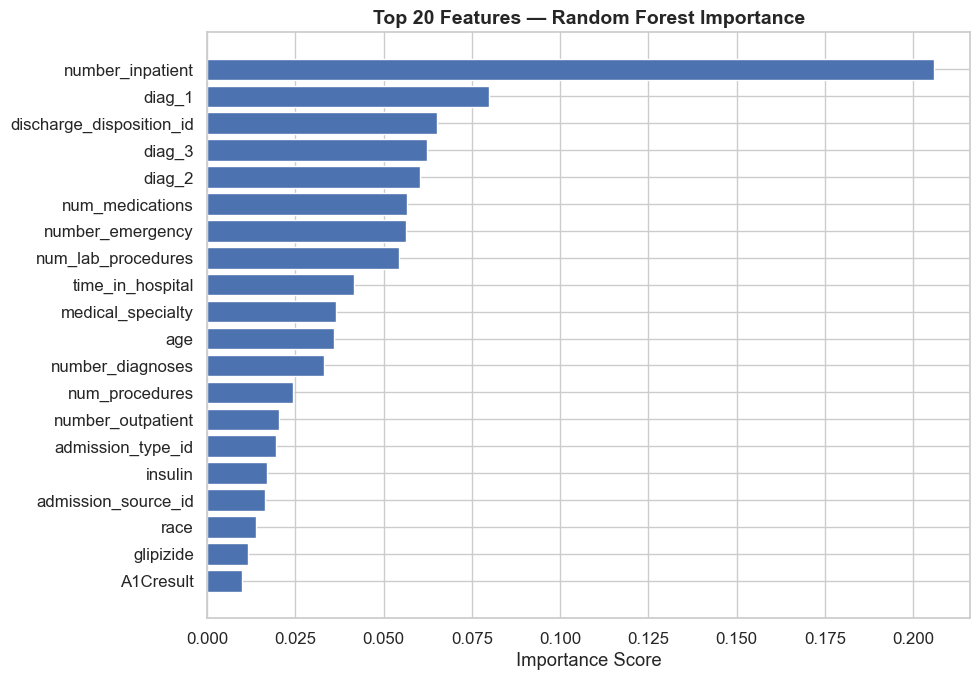

In [27]:
top20 = importance_df.head(20)
fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(top20["feature"][::-1], top20["importance"][::-1], color="#4C72B0")
ax.set_title("Top 20 Features — Random Forest Importance",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

plt.savefig(f"{PLOT_DIR}/07_feature_importance.png", dpi=150)
plt.close()

In [28]:
# Select top 25 features to keep model lean but expressive
TOP_N = 25
selected_features = importance_df.head(TOP_N)["feature"].tolist()
X = X[selected_features]
print(f"\n  Selected top {TOP_N} features for modeling.")


  Selected top 25 features for modeling.


### 6. Model Development

In [29]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)
from xgboost import XGBClassifier
import joblib

In [30]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"  Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train, evaluate and return metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_proba) if y_proba is not None else None

    # Cross-validation F1
    cv_f1 = cross_val_score(model, X_tr, y_tr, cv=5, scoring="f1", n_jobs=-1).mean()

    print(f"\n  ── {name} ──")
    print(f"     Accuracy  : {acc:.4f}")
    print(f"     Precision : {prec:.4f}")
    print(f"     Recall    : {rec:.4f}")
    print(f"     F1-Score  : {f1:.4f}")
    print(f"     ROC-AUC   : {auc:.4f}" if auc else "     ROC-AUC  : N/A")
    print(f"     CV F1     : {cv_f1:.4f}")

    return {
        "model": model, "name": name,
        "accuracy": acc, "precision": prec,
        "recall": rec, "f1": f1,
        "roc_auc": auc, "cv_f1": cv_f1,
        "y_pred": y_pred, "y_proba": y_proba
    }

  Train: 40,581  |  Test: 10,146


In [31]:
# --- Baseline models ---
print("\n  Training baseline models …")

results = {}

results["Logistic Regression"] = evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    X_train, y_train, X_test, y_test
)

results["Random Forest"] = evaluate_model(
    "Random Forest",
    RandomForestClassifier(n_estimators=100, max_depth=15, class_weight="balanced",
                           random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test
)

results["XGBoost"] = evaluate_model(
    "XGBoost",
    XGBClassifier(n_estimators=100, scale_pos_weight=8, max_depth=6,
                  eval_metric="logloss", random_state=42,
                  use_label_encoder=False, verbosity=0, n_jobs=-1),
    X_train, y_train, X_test, y_test
)



  Training baseline models …

  ── Logistic Regression ──
     Accuracy  : 0.6644
     Precision : 0.1644
     Recall    : 0.5169
     F1-Score  : 0.2495
     ROC-AUC   : 0.6469
     CV F1     : 0.2539

  ── Random Forest ──
     Accuracy  : 0.8640
     Precision : 0.2487
     Recall    : 0.1288
     F1-Score  : 0.1697
     ROC-AUC   : 0.6463
     CV F1     : 0.1406

  ── XGBoost ──
     Accuracy  : 0.7327
     Precision : 0.1770
     Recall    : 0.4046
     F1-Score  : 0.2462
     ROC-AUC   : 0.6437
     CV F1     : 0.2445


### 7. Hyperparameter Tuning (Best model)

In [32]:
param_grid = {
    "n_estimators":  [100, 200],
    "max_depth":     [10, 20],
    "min_samples_split": [5, 10],
    "max_features":  ["sqrt"]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_grid, cv=3, scoring="roc_auc", n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)
print(f"  Best params: {rf_grid.best_params_}")
print(f"  Best CV ROC-AUC: {rf_grid.best_score_:.4f}")

best_rf = rf_grid.best_estimator_
results["Random Forest (Tuned)"] = evaluate_model(
    "Random Forest (Tuned)", best_rf, X_train, y_train, X_test, y_test
)

  Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}
  Best CV ROC-AUC: 0.6620

  ── Random Forest (Tuned) ──
     Accuracy  : 0.7383
     Precision : 0.1924
     Recall    : 0.4457
     F1-Score  : 0.2688
     ROC-AUC   : 0.6704
     CV F1     : 0.2630


### 8. Model Comparision & Plots

In [33]:
comparison = pd.DataFrame([
    {
        "Model":     name,
        "Accuracy":  r["accuracy"],
        "Precision": r["precision"],
        "Recall":    r["recall"],
        "F1":        r["f1"],
        "ROC-AUC":   r["roc_auc"],
        "CV-F1":     r["cv_f1"]
    }
    for name, r in results.items()
]).set_index("Model")

print("\n  Model Comparison Table:")
print(comparison.round(4).to_string())

# Save comparison table
comparison.round(4).to_csv(f"{PLOT_DIR}/../model_comparison.csv")


  Model Comparison Table:
                       Accuracy  Precision  Recall      F1  ROC-AUC   CV-F1
Model                                                                      
Logistic Regression      0.6644     0.1644  0.5169  0.2495   0.6469  0.2539
Random Forest            0.8640     0.2487  0.1288  0.1697   0.6463  0.1406
XGBoost                  0.7327     0.1770  0.4046  0.2462   0.6437  0.2445
Random Forest (Tuned)    0.7383     0.1924  0.4457  0.2688   0.6704  0.2630


##### Plot 8: Model comparison bar chart

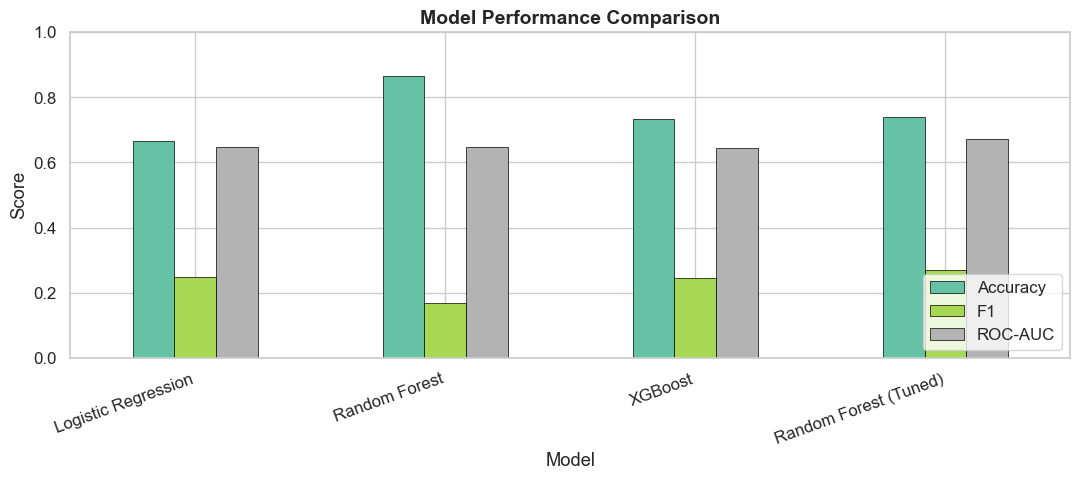

In [34]:
fig, ax = plt.subplots(figsize=(11, 5))
comparison[["Accuracy", "F1", "ROC-AUC"]].plot(
    kind="bar", ax=ax, colormap="Set2", edgecolor="black", linewidth=0.5
)
ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.savefig(f"{PLOT_DIR}/08_model_comparison.png", dpi=150)
plt.close()

In [35]:
# Identify best model by ROC-AUC
best_name = comparison["ROC-AUC"].idxmax()
best_result = results[best_name]
print(f"\n  Best model: {best_name}  (ROC-AUC = {best_result['roc_auc']:.4f})")


  Best model: Random Forest (Tuned)  (ROC-AUC = 0.6704)


##### Plot 9: Confusion matrix for best model

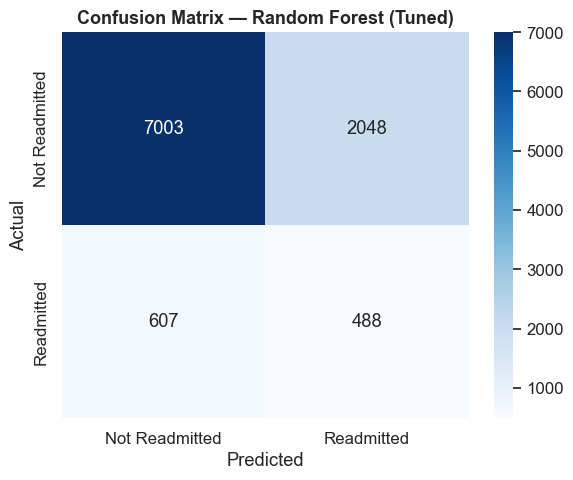

In [36]:
cm = confusion_matrix(y_test, best_result["y_pred"])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Not Readmitted", "Readmitted"],
            yticklabels=["Not Readmitted", "Readmitted"])

ax.set_title(f"Confusion Matrix — {best_name}", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

plt.savefig(f"{PLOT_DIR}/09_confusion_matrix.png", dpi=150)
plt.close()

##### Plot 10: ROC curves

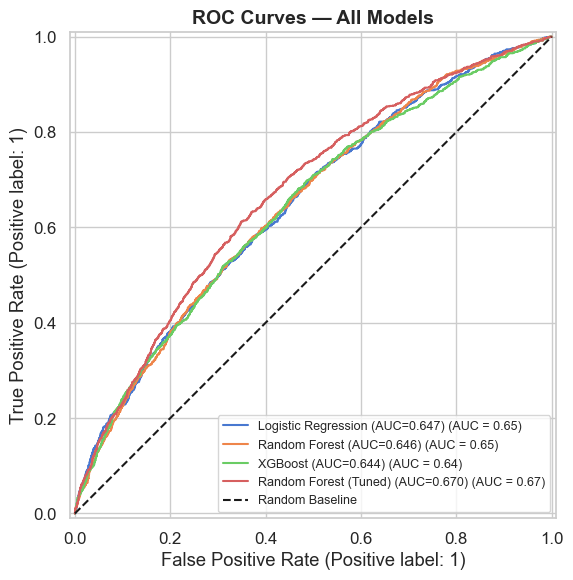

In [37]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, r in results.items():
    if r["y_proba"] is not None:
        RocCurveDisplay.from_predictions(
            y_test, r["y_proba"],
            name=f"{name} (AUC={r['roc_auc']:.3f})",
            ax=ax
        )

ax.plot([0, 1], [0, 1], "k--", label="Random Baseline")
ax.set_title("ROC Curves — All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

plt.savefig(f"{PLOT_DIR}/10_roc_curves.png", dpi=150)
plt.close()

##### Classification report

In [38]:
print(f"\n  Full Classification Report — {best_name}:")
print(classification_report(y_test, best_result["y_pred"],
                             target_names=["Not Readmitted", "Readmitted"]))


  Full Classification Report — Random Forest (Tuned):
                precision    recall  f1-score   support

Not Readmitted       0.92      0.77      0.84      9051
    Readmitted       0.19      0.45      0.27      1095

      accuracy                           0.74     10146
     macro avg       0.56      0.61      0.55     10146
  weighted avg       0.84      0.74      0.78     10146



### 9. Save Model & Artifacts

In [39]:
joblib.dump(best_result["model"], f"{MODEL_DIR}/best_model.pkl")
joblib.dump(scaler,               f"{MODEL_DIR}/scaler.pkl")
joblib.dump(selected_features,    f"{MODEL_DIR}/features.pkl")

print(f"  Saved: best_model.pkl")
print(f"  Saved: scaler.pkl")
print(f"  Saved: features.pkl")
print(f"  Model type: {type(best_result['model']).__name__}")

  Saved: best_model.pkl
  Saved: scaler.pkl
  Saved: features.pkl
  Model type: RandomForestClassifier


### 10. Summary

In [40]:
print(f"  Dataset rows    : {len(df):,}")
print(f"  Features used   : {len(selected_features)}")
print(f"  Best model      : {best_name}")
print(f"  ROC-AUC         : {best_result['roc_auc']:.4f}")
print(f"  F1-Score        : {best_result['f1']:.4f}")
print(f"  Plots saved to  : {PLOT_DIR}/")
print(f"  Model saved to  : {MODEL_DIR}/")

  Dataset rows    : 50,727
  Features used   : 25
  Best model      : Random Forest (Tuned)
  ROC-AUC         : 0.6704
  F1-Score        : 0.2688
  Plots saved to  : ../docs/plots/
  Model saved to  : ../app/model/
